In [1]:
import subprocess, torch

print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
assert torch.cuda.is_available(), "No GPU"
print(torch.cuda.get_device_name(0), torch.version.cuda)

Tue Mar 17 14:37:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

# # All checkpoints will be saved here — survives disconnections
# CHECKPOINT_DIR = Path("/content/drive/MyDrive/RealESRGAN_checkpoints")
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
# print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Mounted at /content/drive


In [3]:
import subprocess, sys
from pathlib import Path

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", *args, "--quiet"], check=True)

pip("install", "torch", "torchvision")
pip("install", "numpy<2")
pip("install", "basicsr", "--no-deps")
pip("install", "facexlib", "--no-deps")
pip("install", "gfpgan", "--no-deps")
pip("install", "realesrgan", "--no-deps")
pip("install", "addict", "future", "lmdb", "Pillow", "pyyaml",
    "requests", "scikit-image", "scipy", "tb-nightly", "tqdm", "yapf", "einops")

# Clone repo
repo_dir = Path("/content/Real-ESRGAN")
if not repo_dir.exists():
    subprocess.run(
        ["git", "clone", "--depth=1",
         "https://github.com/xinntao/Real-ESRGAN.git", str(repo_dir)],
        check=True, capture_output=True
    )

In [4]:
from pathlib import Path
import subprocess, sys

# Patch file on disk BEFORE any import
degradations = Path("/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py")

old = "from torchvision.transforms.functional_tensor import rgb_to_grayscale"
new = "from torchvision.transforms.functional import rgb_to_grayscale"

text = degradations.read_text()
if old in text:
    degradations.write_text(text.replace(old, new))
    print("Patched successfully")
elif new in text:
    print("Already patched")
else:
    for i, line in enumerate(text.splitlines()):
        if "rgb_to_grayscale" in line:
            print(f"Found at line {i}: {repr(line)}")

# Install requirements
%cd /content/Real-ESRGAN
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"], check=True)
print("\nSetup complete")

Patched successfully
/content/Real-ESRGAN

Setup complete


In [5]:
import zipfile, urllib.request
from pathlib import Path

BASE_DIR = Path("/content/datasets/DIV2K")
BASE_DIR.mkdir(parents=True, exist_ok=True)

URLS = {
    "DIV2K_train_HR.zip": "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip",
    "DIV2K_valid_HR.zip": "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",
}

for fname, url in URLS.items():
    zip_path = BASE_DIR / fname
    if not zip_path.exists():
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, zip_path)
    extract_dir = BASE_DIR / fname.replace(".zip", "")
    if not extract_dir.exists():
        print(f"Extracting {fname}...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(BASE_DIR)

# Write meta_info file
meta_info_path = BASE_DIR / "meta_info_DIV2K_train.txt"
train_hr = BASE_DIR / "DIV2K_train_HR"
with open(meta_info_path, "w") as f:
    for img in sorted(train_hr.glob("*.png")):
        f.write(f"{img.name}\n")

print(f"Dataset ready | meta_info: {sum(1 for _ in open(meta_info_path))} images")

Extracting DIV2K_train_HR.zip...
Extracting DIV2K_valid_HR.zip...
Dataset ready | meta_info: 800 images


In [6]:
import os, shutil
from pathlib import Path

exp = Path("/content/Real-ESRGAN/experiments")

# Remove whatever is there (real dir or stale symlink)
if exp.is_symlink():
    exp.unlink()
    print("Removed existing symlink")
elif exp.exists():
    shutil.rmtree(exp)
    print("Removed local experiments dir")

# Create fresh symlink to Drive
os.symlink(
    "/content/drive/MyDrive/RealESRGAN_checkpoints",
    str(exp)
)
print("Symlink created ✓")
print("Points to:", os.readlink(exp))

Removed local experiments dir
Symlink created ✓
Points to: /content/drive/MyDrive/RealESRGAN_checkpoints


In [7]:
from pathlib import Path

# ── Auto-detect latest checkpoint from Drive ──────────────────────────────────
states_dir  = Path("/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/training_states")
state_files = sorted(states_dir.glob("*.state")) if states_dir.exists() else []
latest_state = str(state_files[-1]) if state_files else "~"

if latest_state != "~":
    print(f"Resuming from: {Path(latest_state).name}")
else:
    print("No checkpoint found — training from scratch")

# ── Write config ──────────────────────────────────────────────────────────────
CONFIG_PATH = Path("/content/Real-ESRGAN/options/train_realesrgan_tiny_x4.yml")

CONFIG = f"""
name: RealESRGAN_tiny_x4
model_type: RealESRGANModel
scale: 4
num_gpu: 1
manual_seed: 0

datasets:
  train:
    name: DIV2K
    type: RealESRGANDataset
    dataroot_gt: /content/datasets/DIV2K/DIV2K_train_HR
    meta_info: /content/datasets/DIV2K/meta_info_DIV2K_train.txt
    io_backend:
      type: disk
    gt_size: 256
    use_hflip: true
    use_rot: true
    resize_prob: [0.2, 0.7, 0.1]
    resize_range: [0.15, 1.5]
    gaussian_noise_prob: 0.5
    noise_range: [1, 30]
    poisson_scale_range: [0.05, 3]
    gray_noise_prob: 0.4
    jpeg_range: [30, 95]
    second_blur_prob: 0.8
    resize_prob2: [0.3, 0.4, 0.3]
    resize_range2: [0.3, 1.2]
    gaussian_noise_prob2: 0.5
    noise_range2: [1, 25]
    poisson_scale_range2: [0.05, 2.5]
    gray_noise_prob2: 0.4
    jpeg_range2: [30, 95]
    blur_kernel_size: 21
    kernel_list: [iso, aniso, generalized_iso, generalized_aniso, plateau_iso, plateau_aniso]
    kernel_prob: [0.45, 0.25, 0.12, 0.03, 0.12, 0.03]
    sinc_prob: 0.1
    blur_sigma: [0.2, 3]
    betag_range: [0.5, 4]
    betap_range: [1, 2]
    blur_kernel_size2: 21
    kernel_list2: [iso, aniso, generalized_iso, generalized_aniso, plateau_iso, plateau_aniso]
    kernel_prob2: [0.45, 0.25, 0.12, 0.03, 0.12, 0.03]
    sinc_prob2: 0.1
    blur_sigma2: [0.2, 1.5]
    betag_range2: [0.5, 4]
    betap_range2: [1, 2]
    final_sinc_prob: 0.8
    l1_gt_usm: true
    percep_gt_usm: true
    gan_gt_usm: false
    queue_size: 160
    num_worker_per_gpu: 4
    batch_size_per_gpu: 8
    dataset_enlarge_ratio: 1
    prefetch_mode: ~

  val:
    name: DIV2K_valid
    type: PairedImageDataset
    dataroot_gt: /content/datasets/DIV2K/DIV2K_valid_HR
    dataroot_lq: /content/datasets/DIV2K/DIV2K_valid_HR
    io_backend:
      type: disk

network_g:
  type: RRDBNet
  num_in_ch: 3
  num_out_ch: 3
  num_feat: 64
  num_block: 6
  num_grow_ch: 32
  scale: 4

network_d:
  type: UNetDiscriminatorSN
  num_in_ch: 3
  num_feat: 64
  skip_connection: True

path:
  pretrain_network_g: ~
  strict_load_g: true
  resume_state: {latest_state}
  experiments_root: /content/Real-ESRGAN/experiments

train:
  ema_decay: 0.999
  optim_g:
    type: Adam
    lr: !!float 1e-4
    weight_decay: 0
    betas: [0.9, 0.99]
  optim_d:
    type: Adam
    lr: !!float 1e-4
    weight_decay: 0
    betas: [0.9, 0.99]
  scheduler:
    type: MultiStepLR
    milestones: [100000, 200000]
    gamma: 0.5
  total_iter: 50000
  warmup_iter: -1
  pixel_opt:
    type: L1Loss
    loss_weight: 1.0
    reduction: mean
  perceptual_opt:
    type: PerceptualLoss
    layer_weights:
      conv1_2: 0.1
      conv2_2: 0.1
      conv3_4: 1
      conv4_4: 1
      conv5_4: 1
    vgg_type: vgg19
    use_input_norm: true
    perceptual_weight: !!float 1.0
    style_weight: 0
    range_norm: false
    criterion: l1
  gan_opt:
    type: GANLoss
    gan_type: vanilla
    real_label_val: 1.0
    fake_label_val: 0.0
    loss_weight: !!float 1e-1
  net_d_iters: 1
  net_d_init_iters: 0

logger:
  print_freq: 100
  save_checkpoint_freq: 500
  use_tb_logger: true
  wandb:
    project: ~
    resume_id: ~

dist_params:
  backend: nccl
  port: 29500
"""

CONFIG_PATH.write_text(CONFIG.strip())
print(f"Config written — resume_state: {latest_state}")

Resuming from: 47500.state
Config written — resume_state: /content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/training_states/47500.state


In [8]:
from pathlib import Path

base = Path("/content/drive/MyDrive/RealESRGAN_checkpoints")
print("All contents recursively:")
for p in sorted(base.rglob("*")):
    print(p)

All contents recursively:
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_1000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_10000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_11000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_12000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_13000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_14000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_15000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_16000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_d_17000.pth
/content/drive/MyDrive/RealESRGAN_checkpoints/

In [9]:
from pathlib import Path

model_path = Path("/usr/local/lib/python3.12/dist-packages/realesrgan/models/realesrgan_model.py")
text = model_path.read_text()

old = "    def __init__(self, opt):\n        super(RealESRGANModel, self).__init__(opt)"
new = """    def __init__(self, opt):
        super(RealESRGANModel, self).__init__(opt)
        # Merge dataset train config into self.opt so resize_prob etc. are accessible
        train_cfg = opt.get('datasets', {}).get('train', {})
        self.opt.update(train_cfg)"""

if old in text:
    model_path.write_text(text.replace(old, new))
    print("Patched successfully")
elif "Merge dataset train config" in text:
    print("Already patched")
else:
    print("Pattern not found")

Patched successfully


In [10]:
# import subprocess, sys

# cmd = [
#     sys.executable,
#     "/content/Real-ESRGAN/realesrgan/train.py",
#     "-opt", "/content/Real-ESRGAN/options/train_realesrgan_tiny_x4.yml",
#     "--auto_resume",
# ]

# proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
#                         universal_newlines=True, bufsize=1)
# for line in proc.stdout:
#     print(line, end="")
# proc.wait()
# print("Done" if proc.returncode == 0 else f"Failed with code {proc.returncode}")
import subprocess, sys, time, shutil, threading
from pathlib import Path

DRIVE_CKPT_DIR = Path("/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4")
LOCAL_CKPT_DIR = Path("/content/Real-ESRGAN/experiments/RealESRGAN_tiny_x4")
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

def sync_checkpoints():
    """Runs in background — copies new checkpoints to Drive every 10 minutes."""
    while not stop_sync.is_set():
        time.sleep(600)  # every 10 minutes
        if LOCAL_CKPT_DIR.exists():
            for subdir in ["models", "training_states"]:
                src = LOCAL_CKPT_DIR / subdir
                dst = DRIVE_CKPT_DIR / subdir
                if src.exists():
                    dst.mkdir(parents=True, exist_ok=True)
                    for f in src.glob("*"):
                        dst_file = dst / f.name
                        if not dst_file.exists():
                            shutil.copy2(f, dst_file)
                            print(f"[sync] Saved → Drive: {f.name}")

# Start background sync thread
stop_sync = threading.Event()
sync_thread = threading.Thread(target=sync_checkpoints, daemon=True)
sync_thread.start()
print("Background checkpoint sync started (every 10 min)")

# Run training
cmd = [
    sys.executable,
    "/content/Real-ESRGAN/realesrgan/train.py",
    "-opt", "/content/Real-ESRGAN/options/train_realesrgan_tiny_x4.yml",
    "--auto_resume",
]

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        universal_newlines=True, bufsize=1)
for line in proc.stdout:
    print(line, end="")
proc.wait()

# Stop background thread
stop_sync.set()

# Final sync — copy everything to Drive after training ends
print("\nRunning final checkpoint sync to Drive...")
if LOCAL_CKPT_DIR.exists():
    for subdir in ["models", "training_states", "log"]:
        src = LOCAL_CKPT_DIR / subdir
        dst = DRIVE_CKPT_DIR / subdir
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            for f in src.glob("*"):
                shutil.copy2(f, dst / f.name)
            print(f"[final sync] {subdir}/ → Drive ({len(list(src.glob('*')))} files)")

# Verify
print("\nCheckpoints saved to Drive:")
for f in sorted(DRIVE_CKPT_DIR.rglob("*.pth")):
    print(f"  {f.name}  {f.stat().st_size / 1e6:.1f} MB")

print("\nDone" if proc.returncode == 0 else f"Failed with code {proc.returncode}")

Background checkpoint sync started (every 10 min)
Disable distributed.
2026-03-17 14:42:05,709 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)
    
Version Information: 
	BasicSR: 1.4.2
	PyTorch: 2.10.0+cu128
	TorchVision: 0.25.0+cu128
2026-03-17 14:42:05,711 INFO: 
  name: RealESRGAN_tiny_x4
  model_type: RealESRGANModel
  scale: 4
  num_gpu: 1
  manual_seed: 0
  datasets:[
    train:[
      name: DIV2K
      type: RealESRGANDataset
   

SameFileError: PosixPath('/content/Real-ESRGAN/experiments/RealESRGAN_tiny_x4/models/net_g_1000.pth') and PosixPath('/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models/net_g_1000.pth') are the same file

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/Real-ESRGAN/experiments/RealESRGAN_tiny_x4/log

In [11]:
from pathlib import Path

ckpt_dir = Path("/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models")
files = sorted(ckpt_dir.glob("net_g_*.pth"))

if files:
    for f in files:
        print(f.name, f"{f.stat().st_size / 1e6:.1f} MB")
else:
    print("No checkpoints yet — training may still be in progress")

net_g_1000.pth 35.9 MB
net_g_10000.pth 35.9 MB
net_g_11000.pth 35.9 MB
net_g_12000.pth 35.9 MB
net_g_13000.pth 35.9 MB
net_g_14000.pth 35.9 MB
net_g_15000.pth 35.9 MB
net_g_16000.pth 35.9 MB
net_g_17000.pth 35.9 MB
net_g_18000.pth 35.9 MB
net_g_19000.pth 35.9 MB
net_g_2000.pth 35.9 MB
net_g_20000.pth 35.9 MB
net_g_21000.pth 35.9 MB
net_g_22000.pth 35.9 MB
net_g_23000.pth 35.9 MB
net_g_24000.pth 35.9 MB
net_g_24500.pth 35.9 MB
net_g_25000.pth 35.9 MB
net_g_25500.pth 35.9 MB
net_g_26000.pth 35.9 MB
net_g_26500.pth 35.9 MB
net_g_27000.pth 35.9 MB
net_g_27500.pth 35.9 MB
net_g_28000.pth 35.9 MB
net_g_28500.pth 35.9 MB
net_g_29000.pth 35.9 MB
net_g_29500.pth 35.9 MB
net_g_3000.pth 35.9 MB
net_g_30000.pth 35.9 MB
net_g_30500.pth 35.9 MB
net_g_31000.pth 35.9 MB
net_g_31500.pth 35.9 MB
net_g_32000.pth 35.9 MB
net_g_32500.pth 35.9 MB
net_g_33000.pth 35.9 MB
net_g_33500.pth 35.9 MB
net_g_34000.pth 35.9 MB
net_g_34500.pth 35.9 MB
net_g_35000.pth 35.9 MB
net_g_35500.pth 35.9 MB
net_g_36000.pth 35.

In [12]:
import torch
from pathlib import Path
from basicsr.archs.rrdbnet_arch import RRDBNet

models_dir   = Path("/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models")
latest_model = sorted(models_dir.glob("net_g_*.pth"))[-1]
ckpt         = torch.load(latest_model, map_location="cpu")

model = RRDBNet(
    num_in_ch=3, num_out_ch=3,
    num_feat=64, num_block=6,
    num_grow_ch=32, scale=4
)

print("=" * 55)
print("  MODEL PARAMETERS")
print("=" * 55)
print(f"  Checkpoint        : {latest_model.name}")
print(f"  Architecture      : RRDBNet (Real-ESRGAN 6-block)")
print(f"  Scale factor      : 4x")
print(f"  RRDB blocks       : 6")
print(f"  Feature channels  : 64")
print(f"  Growth channels   : 32")
print(f"  Input channels    : 3 (RGB)")
print(f"  Output channels   : 3 (RGB)")
print(f"  Total parameters  : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable params  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Checkpoint keys   : {list(ckpt.keys())}")
print("=" * 55)
print("\n  TRAINING CONFIG")
print("=" * 55)
print(f"  Total iterations  : 50,000")
print(f"  Batch size        : 8")
print(f"  Learning rate G   : 1e-4")
print(f"  Learning rate D   : 1e-4")
print(f"  LR scheduler      : MultiStepLR [100k, 200k], gamma=0.5")
print(f"  EMA decay         : 0.999")
print(f"  GT crop size      : 256x256")
print(f"  Checkpoint freq   : every 500 iters")
print(f"  Loss - Pixel      : L1, weight=1.0")
print(f"  Loss - Perceptual : VGG19, weight=1.0")
print(f"  Loss - GAN        : Vanilla, weight=0.1")
print(f"  Dataset           : DIV2K (800 train / 100 val)")
print(f"  Workers per GPU   : 4")
print(f"  Queue size        : 160")
print("=" * 55)

  MODEL PARAMETERS
  Checkpoint        : net_g_latest.pth
  Architecture      : RRDBNet (Real-ESRGAN 6-block)
  Scale factor      : 4x
  RRDB blocks       : 6
  Feature channels  : 64
  Growth channels   : 32
  Input channels    : 3 (RGB)
  Output channels   : 3 (RGB)
  Total parameters  : 4,467,779
  Trainable params  : 4,467,779
  Checkpoint keys   : ['params', 'params_ema']

  TRAINING CONFIG
  Total iterations  : 50,000
  Batch size        : 8
  Learning rate G   : 1e-4
  Learning rate D   : 1e-4
  LR scheduler      : MultiStepLR [100k, 200k], gamma=0.5
  EMA decay         : 0.999
  GT crop size      : 256x256
  Checkpoint freq   : every 500 iters
  Loss - Pixel      : L1, weight=1.0
  Loss - Perceptual : VGG19, weight=1.0
  Loss - GAN        : Vanilla, weight=0.1
  Dataset           : DIV2K (800 train / 100 val)
  Workers per GPU   : 4
  Queue size        : 160


In [15]:
subprocess.run(
    [sys.executable, "setup.py", "develop"],
    cwd=str(repo_dir), capture_output=True
)

CompletedProcess(args=['/usr/bin/python3', 'setup.py', 'develop'], returncode=0, stdout=b"running develop\nrunning egg_info\ncreating realesrgan.egg-info\nwriting realesrgan.egg-info/PKG-INFO\nwriting dependency_links to realesrgan.egg-info/dependency_links.txt\nwriting requirements to realesrgan.egg-info/requires.txt\nwriting top-level names to realesrgan.egg-info/top_level.txt\nwriting manifest file 'realesrgan.egg-info/SOURCES.txt'\nreading manifest file 'realesrgan.egg-info/SOURCES.txt'\nreading manifest template 'MANIFEST.in'\nadding license file 'LICENSE'\nwriting manifest file 'realesrgan.egg-info/SOURCES.txt'\nrunning build_ext\nCreating /usr/local/lib/python3.12/dist-packages/realesrgan.egg-link (link to .)\nAdding realesrgan 0.3.0 to easy-install.pth file\n\nInstalled /content/Real-ESRGAN\nProcessing dependencies for realesrgan==0.3.0\nSearching for tqdm==4.67.3\nBest match: tqdm 4.67.3\nAdding tqdm 4.67.3 to easy-install.pth file\nInstalling tqdm script to /usr/local/bin\n\n

Test image saved → /content/test_input.jpg
Using model: net_g_latest.pth
Input size : 128x128
	Tile 1/1
Output size: 512x512

Input (left) vs Enhanced (right):


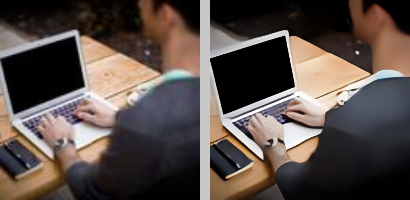

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import cv2
import torch
import numpy as np
import urllib.request
from pathlib import Path
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer
from google.colab import files
from IPython.display import display, Image as IPImage

# ── Download test image (no upload needed) ────────────────────────────────────
print("Downloading test image...")
urllib.request.urlretrieve(
    "https://picsum.photos/id/1/128/128",
    "/content/test_input.jpg"
)
test_img_path = "/content/test_input.jpg"
print(f"Test image saved → {test_img_path}")

# ── Load model ────────────────────────────────────────────────────────────────
models_dir   = Path("/content/drive/MyDrive/RealESRGAN_checkpoints/RealESRGAN_tiny_x4/models")
latest_model = sorted(models_dir.glob("net_g_*.pth"))[-1]
print(f"Using model: {latest_model.name}")

model = RRDBNet(
    num_in_ch=3, num_out_ch=3,
    num_feat=64, num_block=6,
    num_grow_ch=32, scale=4
)

upsampler = RealESRGANer(
    scale=4,
    model_path=str(latest_model),
    model=model,
    tile=400,
    tile_pad=10,
    pre_pad=0,
    half=torch.cuda.is_available()
)

# ── Run inference ─────────────────────────────────────────────────────────────
img = cv2.imread(test_img_path, cv2.IMREAD_COLOR)   # force 3-channel BGR
if img is None:
    raise FileNotFoundError(f"Could not read image: {test_img_path}")

print(f"Input size : {img.shape[1]}x{img.shape[0]}")
output, _ = upsampler.enhance(img, outscale=4)
print(f"Output size: {output.shape[1]}x{output.shape[0]}")

output_path = "/content/test_output.png"
cv2.imwrite(output_path, output)

# ── Display side by side (fixed channel handling) ─────────────────────────────
display_h = 200
w_in      = int(img.shape[1]    * display_h / img.shape[0])
w_out     = int(output.shape[1] * display_h / output.shape[0])

img_disp    = cv2.resize(img,    (w_in,  display_h))
output_disp = cv2.resize(output, (w_out, display_h))

# Ensure both are 3-channel before stacking
if img_disp.ndim == 2:
    img_disp = cv2.cvtColor(img_disp, cv2.COLOR_GRAY2BGR)
if img_disp.shape[2] == 4:
    img_disp = cv2.cvtColor(img_disp, cv2.COLOR_BGRA2BGR)

divider     = np.full((display_h, 10, 3), 200, dtype=np.uint8)
side_by_side = np.hstack([img_disp, divider, output_disp])
cv2.imwrite("/content/comparison.png", side_by_side)

print("\nInput (left) vs Enhanced (right):")
display(IPImage("/content/comparison.png"))

# ── Download output ───────────────────────────────────────────────────────────
files.download(output_path)
